# Stepsizes

[0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14
 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28
 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42
 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52]
[ 1.21  2.42  3.63  4.84  6.05  7.26  8.47  9.68 10.89 12.1  13.31 14.52
 15.73 16.94 18.15 19.36 20.57 21.78 22.99 24.2  25.41 26.62 27.83 29.04
 30.25 31.46 32.67 33.88 35.09 36.3  37.51 38.72 39.93 41.14 42.35 43.56
 44.77 45.98 47.19 48.4  49.61 50.82 52.03 53.24 54.45 55.66 56.87 58.08
 59.29 60.5  61.71 62.92]
[1.         1.5        1.83333333 2.08333333 2.28333333 2.45
 2.59285714 2.71785714 2.82896825 2.92896825 3.01987734 3.10321068
 3.18013376 3.25156233 3.31822899 3.38072899 3.43955252 3.49510808
 3.54773966 3.59773966 3.6453587  3.69081325 3.73429151 3.77595818
 3.81595818 3.85441972 3.89145675 3.92717104 3.9616538  3.99498713
 4.0272452  4.0584952  4.08879823 4.11820999 4.14678142 4.1745592
 4.20158622 4.22790201

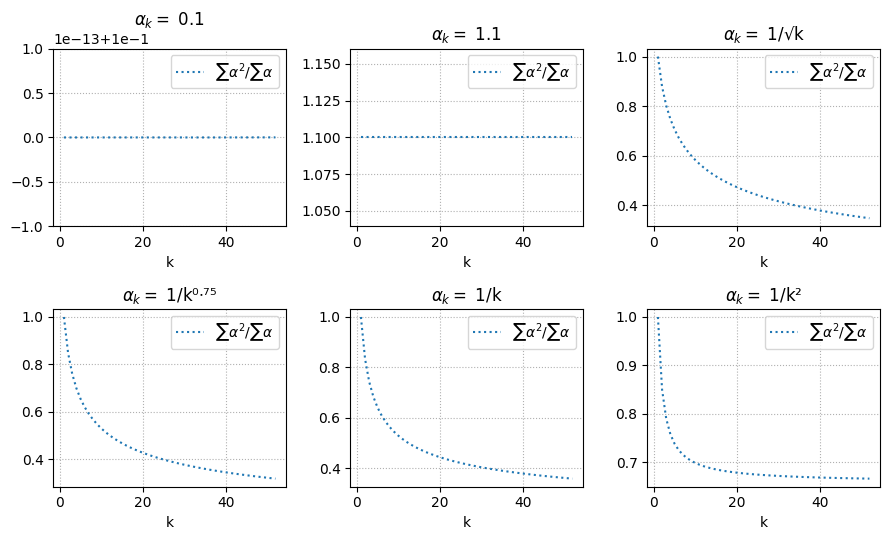

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Maximum iteration count
max_k = 52
k_vals = np.arange(1, max_k + 1)

# Define six different step-size functions (lambda functions)
step_functions = {
    "0.1": lambda k: 0.1,
    "1.1": lambda k: 1.1,
    "1/√k": lambda k: 1 / np.sqrt(k),
    "1/k⁰ᐧ⁷⁵": lambda k: 1 / (k**0.75),
    "1/k": lambda k: 1 / k,
    "1/k²": lambda k: 1 / k**2,
}

# Create a figure with 2x3 subplots
fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

# Loop over the step-size functions and plot each in a separate subplot
for i, (label, alpha_func) in enumerate(step_functions.items()):
    ax = axes[i]
    
    # Compute alpha_k for each k
    alphas = np.array([alpha_func(k) for k in k_vals])
    
    # Compute the partial sums: sum(alpha_i) and sum(alpha_i^2)
    partial_sum = np.cumsum(alphas)
    partial_sum_sq = np.cumsum(alphas**2)
    print(partial_sum_sq)
    
    # Plot the partial sums for alpha and for alpha^2
    # ax.plot(k_vals, partial_sum, label=r"$\sum \alpha$")
    # ax.plot(k_vals, partial_sum_sq, label=r"$\sum \alpha^2$", linestyle="--")
    ax.plot(k_vals, partial_sum_sq/partial_sum, label=r"$\sum \alpha^2$/$\sum \alpha$", linestyle=":")
    
    # Add labels, title, and legend
    ax.set_xlabel("k")
    # ax.set_ylabel("Partial Sum")
    ax.set_title(r"$\alpha_k =$ " + label)
    ax.legend()
    ax.grid(linestyle=":")

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the figure with all subplots
plt.savefig("step_sizes.pdf")
plt.show()

# Strongly convex non-smooth function

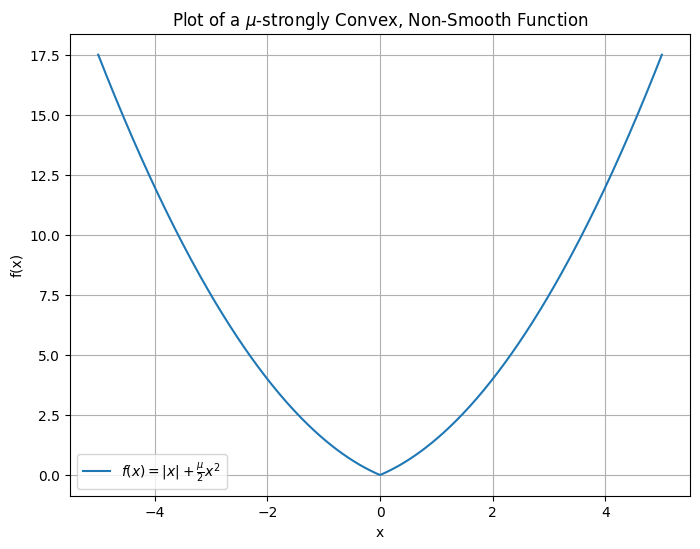

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set the strong convexity parameter
mu = 1.0

# Create an array of x values
x = np.linspace(-5, 5, 400)

# Define the function: f(x) = |x| + (mu/2)*x^2
f = np.abs(x) + 0.5 * mu * x**2

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(x, f, label=r'$f(x)=|x|+\frac{\mu}{2}x^2$')
plt.title(r'Plot of a $\mu$-strongly Convex, Non-Smooth Function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()


# Linear Least squares with $\ell_1$

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import jax
from jax import numpy as jnp, grad, jit
from scipy.optimize import minimize_scalar
import time
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression

# Set a random seed for reproducibility
jax.config.update("jax_enable_x64", True)

def fix_seed(seed=228):
    np.random.seed(seed)
    jax.random.PRNGKey(seed)

# Define the linear least squares loss function
@jit
def least_squares_loss(w, X, y):
    m = len(X)
    predictions = X @ w
    return (1/(2*m)) * jnp.sum((predictions - y) ** 2)

# Compute the optimal solution using CVXPY
def compute_optimal(X, y, lam):
    m, n = X.shape
    
    # Define the variable for weights
    w = cp.Variable(n)
    
    # Construct the objective: least squares loss + L1 regularization
    predictions = X @ w
    least_squares = (1/(2*m)) * cp.sum_squares(predictions - y)
    l1_reg = lam * cp.norm1(w)
    
    # Total loss
    loss = least_squares + l1_reg
    
    # Define the problem
    problem = cp.Problem(cp.Minimize(loss))
    
    # Solve the problem
    problem.solve()
    
    # Extract the optimal weights and minimum loss
    w_star = w.value
    f_star = problem.value
    
    return w_star, f_star

# Generate synthetic regression problem
def generate_problem(params):
    fix_seed()
    m = params["m"]  # number of samples
    n = params["n"]  # number of features
    noise = params.get("noise", 0.1)
    
    # Get spectrum bounds
    mu = params.get("mu", 0.0)  # minimum eigenvalue
    L = params.get("L", 10.0)   # maximum eigenvalue
    
    # Generate random orthogonal matrix for eigenvectors
    Q, _ = np.linalg.qr(np.random.randn(n, n))
    
    eigenvalues = np.linspace(mu, L, n)*m
   
    # Create data matrix X directly using the eigenvalues and eigenvectors
    # X = U * sqrt(S) where U is random orthogonal and S contains eigenvalues
    # This ensures X^T X has the desired eigenvalues
    
    # Generate random orthonormal matrix for U (m x n)
    if m >= n:
        # If m >= n, we can generate a full orthogonal matrix
        U, _ = np.linalg.qr(np.random.randn(n, n))
    else:
        # If m < n, we need a different approach
        temp, _ = np.linalg.qr(np.random.randn(n, n))
        U = np.zeros((n, m))
        U[:, :m] = temp
    
    # Create X such that X^T X has the desired eigenvalues
    X = U @ np.diag(np.sqrt(eigenvalues)) @ Q.T
    
    # Generate true coefficients
    coef = np.random.randn(n)
    
    # Apply sparsity if specified
    sparsity = params.get("sparsity", 0.0)
    if sparsity > 0:
        zero_indices = np.random.choice(n, int(n * sparsity), replace=False)
        coef[zero_indices] = 0
    
    # Generate target values
    y = X @ coef + noise * np.random.randn(n)
    
    # Verify the actual condition number
    H = X.T @ X / m
    actual_eigenvalues = np.linalg.eigvalsh(H)
    actual_mu = np.min(actual_eigenvalues)
    actual_L = np.max(actual_eigenvalues)
    
    condition_str = "infinite" if mu == 0 else f"{L/mu:.6f}"
    print(f"Requested spectrum bounds: mu={mu}, L={L}, condition number={condition_str}")
    print(f"Actual spectrum bounds: mu={actual_mu:.6f}, L={actual_L:.6f}, condition number={actual_L/actual_mu:.6f}")
    
    return X, y

# Helper function to create a 1/sqrt(k) learning rate strategy
def create_1_over_sqrt_k_lr(alpha):
    """
    Creates a learning rate function that returns alpha/sqrt(k) where k is the iteration number.
    
    Args:
        alpha: Scaling factor for the learning rate
        
    Returns:
        A function that takes an iteration number k and returns alpha/sqrt(k)
    """
    def one_over_sqrt_k_lr(k):
        # Avoid division by zero for k=0
        k_safe = max(k, 1)
        return alpha / (k_safe**0.5)
    
    return one_over_sqrt_k_lr

# Helper function to create a 1/k learning rate strategy
def create_1_over_k_lr(alpha):
    """
    Creates a learning rate function that returns alpha/k where k is the iteration number.
    
    Args:
        alpha: Scaling factor for the learning rate
        
    Returns:
        A function that takes an iteration number k and returns alpha/k
    """
    def one_over_k_lr(k):
        # Avoid division by zero for k=0
        k_safe = max(k, 1)
        return alpha / k_safe
    
    return one_over_k_lr

# Subgradient descent method
def subgradient_descent(w_0, X, y, learning_rate, num_iters, lam):
    fix_seed()
    trajectory = [w_0]
    times = [0]
    gradients = []
    
    w = w_0
    f = lambda w: least_squares_loss(w, X, y)
    
    iter_start = time.time()
    for i in range(num_iters):
        # Determine the current learning rate
        if callable(learning_rate):
            # If learning_rate is a function, call it with the current iteration
            current_lr = learning_rate(i+1)
        else:
            # Otherwise, use the constant learning rate
            current_lr = learning_rate
            
        grad_val = grad(f)(w)
        subgrad_val = grad_val + lam * jnp.sign(w)
        gradients.append(jnp.linalg.norm(subgrad_val))
        
        w = w - current_lr * subgrad_val
        
        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)
    
    return trajectory, times, gradients

# Soft thresholding operator for proximal gradient method
def soft_thresholding(x, kappa):
    return jnp.sign(x) * jnp.maximum(jnp.abs(x) - kappa, 0)

# Proximal gradient method (ISTA)
def proximal_gradient_method(w_0, X, y, learning_rate, num_iters, lam):
    trajectory = [w_0]
    times = [0]
    gradients = []
    
    w = w_0
    f = lambda w: least_squares_loss(w, X, y)
    
    iter_start = time.time()
    for i in range(num_iters):
        grad_val = grad(f)(w)
        gradients.append(jnp.linalg.norm(grad_val))
        
        w = soft_thresholding(w - learning_rate * grad_val, learning_rate * lam)
        
        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)
    
    return trajectory, times, gradients

# Accelerated proximal gradient method (FISTA)
def accelerated_proximal_gradient(w_0, X, y, learning_rate, num_iters, lam):
    trajectory = [w_0]
    times = [0]
    gradients = []
    
    w = w_0
    z = w_0
    t = 1
    
    f = lambda w: least_squares_loss(w, X, y)
    
    iter_start = time.time()
    for i in range(num_iters):
        grad_val = grad(f)(z)
        gradients.append(jnp.linalg.norm(grad_val))
        
        w_next = soft_thresholding(z - learning_rate * grad_val, learning_rate * lam)
        
        t_next = (1 + jnp.sqrt(1 + 4 * t**2)) / 2
        z = w_next + ((t - 1) / t_next) * (w_next - w)
        
        w = w_next
        t = t_next
        
        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)
    
    return trajectory, times, gradients

# Compute MSE
def compute_mse(w, X, y):
    predictions = X @ w
    return jnp.mean((predictions - y) ** 2)

# Compute metrics
def compute_metrics(trajectory, x_star, f_star, gradients, times, X, y, lam):
    f = lambda w: least_squares_loss(w, X, y) + lam * jnp.sum(jnp.abs(w))
    
    metrics = {
        "f_gap": [jnp.abs(f(x) - f_star) for x in trajectory],
        "x_gap": [jnp.linalg.norm(x - x_star) for x in trajectory],
        "grad_norm": gradients,
        "time": times,
        # "mse": [compute_mse(x, X, y) for x in trajectory],
        "sparsity": [jnp.mean(jnp.abs(x) < 1e-5) for x in trajectory]
    }
    return metrics

def run_experiments(params):
    lam = params["lambda"]
    methods = params["methods"]
    results = {}

    X, y = generate_problem(params)
    n_features = X.shape[1]
    
    # Initialize with zeros
    x_0 = jax.random.normal(jax.random.PRNGKey(0), (n_features, ))
    
    # Compute optimal solution
    x_star, f_star = compute_optimal(X, y, lam)
    optimal_sparsity = np.mean(np.abs(x_star) < 1e-5)
    print(f"Optimal solution sparsity: {optimal_sparsity:.2e}")
    params["optimal_sparsity"] = optimal_sparsity
    # print(f"Optimal MSE: {compute_mse(x_star, X, y):.4f}")

    for method in methods:
        if method["method"] == "Subgrad":
            learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            
            # Handle different learning rate strategies
            if isinstance(learning_rate, (int, float)):
                # Constant learning rate
                lr_label = f" lr {learning_rate:.1e}"
            elif callable(learning_rate):
                # Try to determine the type of learning rate scheduler
                if hasattr(learning_rate, "__name__"):
                    if learning_rate.__name__ == "one_over_k_lr":
                        # 1/k learning rate
                        alpha = learning_rate.__closure__[0].cell_contents
                        lr_label = f" lr α/k (α={alpha:.1e})"
                    elif learning_rate.__name__ == "one_over_sqrt_k_lr":
                        # 1/sqrt(k) learning rate
                        alpha = learning_rate.__closure__[0].cell_contents
                        lr_label = f" lr α/√k (α={alpha:.1e})"
                    else:
                        lr_label = " lr custom"
                elif hasattr(learning_rate, "__closure__") and learning_rate.__closure__:
                    # Try to extract the alpha value from the closure
                    try:
                        alpha = learning_rate.__closure__[0].cell_contents
                        # Check the function body to determine if it's 1/k or 1/sqrt(k)
                        func_code = learning_rate.__code__.co_consts
                        if any("k**0.5" in str(const) for const in func_code if isinstance(const, str)):
                            lr_label = f" lr α/√k (α={alpha:.1e})"
                        elif any("k**1" in str(const) for const in func_code if isinstance(const, str)):
                            lr_label = f" lr α/k (α={alpha:.1e})"
                        else:
                            lr_label = " lr custom"
                    except:
                        lr_label = " lr custom"
                else:
                    lr_label = " lr custom"
            else:
                # Default to unknown if not recognized
                lr_label = " lr unknown"
                
            trajectory, times, gradients = subgradient_descent(x_0, X, y, learning_rate, iterations, lam)
            label = method["method"] + lr_label
            results[label] = compute_metrics(trajectory, x_star, f_star, gradients, times, X, y, lam)
        
        elif method["method"] == "Proximal":
            learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            trajectory, times, gradients = proximal_gradient_method(x_0, X, y, learning_rate, iterations, lam)
            label = method["method"] + f" lr {learning_rate:.1e}"
            results[label] = compute_metrics(trajectory, x_star, f_star, gradients, times, X, y, lam)
        
        elif method["method"] == "FISTA":
            learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            trajectory, times, gradients = accelerated_proximal_gradient(x_0, X, y, learning_rate, iterations, lam)
            label = method["method"] + f" lr {learning_rate:.1e}"
            results[label] = compute_metrics(trajectory, x_star, f_star, gradients, times, X, y, lam)

    return results, params

def plot_results(results, params):
    plt.figure(figsize=(9, 3))
    lam = params["lambda"]
    
    plt.suptitle(f"Linear Least Squares with $\ell_1$ Regularization (LASSO).\n m={params['m']}, n={params['n']}, λ={lam}, μ={params['mu']}, L={params['L']}. Optimal sparsity: {params['optimal_sparsity']:.1e}")

    # Plot function gap vs iterations
    plt.subplot(1, 3, 1)
    for method, metrics in results.items():
        plt.plot(metrics['f_gap'], label=method + f". Sparsity {metrics['sparsity'][-1]:.1e}")
    plt.xlabel('Iteration')
    plt.ylabel(r'$|f(x_k) - f^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")
    plt.title('Function Gap')

    # Plot distance to optimal solution vs iterations
    plt.subplot(1, 3, 2)
    for method, metrics in results.items():
        plt.plot(metrics['x_gap'])
    plt.xlabel('Iteration')
    plt.ylabel(r'$\|x_k - x^*\|$')
    plt.yscale('log')
    plt.grid(linestyle=":")
    plt.title('Distance to Optimal Solution')

    # Plot gradient norm vs iterations
    plt.subplot(1, 3, 3)
    for method, metrics in results.items():
        plt.plot(metrics['grad_norm'])
    plt.xlabel('Iteration')
    plt.ylabel(r'$\|g_k\|$')
    plt.yscale('log')
    plt.grid(linestyle=":")
    plt.title('Subgradient Norm')

    # Place the legend below the plots
    plt.figlegend(loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.01))
    
    # Adjust layout to make space for the legend below
    filename = f"lasso_m_{params['m']}_n_{params['n']}_mu_{params['mu']}_lambda_{params['lambda']}.pdf"
    plt.tight_layout(rect=[0, 0.1, 1, 1.05])
    plt.savefig(filename)
    plt.show()

Requested spectrum bounds: mu=0, L=10, condition number=infinite
Actual spectrum bounds: mu=-0.000000, L=10.000000, condition number=-3465176107614003.500000
Optimal solution sparsity: 0.00e+00


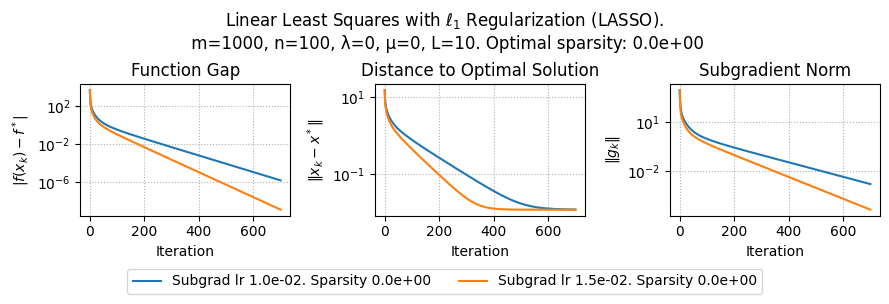

In [226]:
problem_params = {
    "m": 1000,  # number of samples
    "n": 100,   # number of features
    "mu": 0,    # strong convexity parameter (0 for LASSO)
    "L": 10,     # smoothness parameter
    "lambda": 0,  # regularization parameter
    "sparsity": 0,  # target sparsity of the true solution
    "noise": 0.1,     # noise level
    "methods": [
        {"method": "Subgrad", "learning_rate": 1e-2, "iterations": 700},
        {"method": "Subgrad", "learning_rate": 1.5e-2, "iterations": 700},
        # {"method": "Proximal", "learning_rate": 0.1, "iterations": 200},
        # {"method": "FISTA", "learning_rate": 0.1, "iterations": 200}
    ]
}

# Run experiments
results, params = run_experiments(problem_params)

# Plot results
plot_results(results, params)

Requested spectrum bounds: mu=0, L=10, condition number=infinite
Actual spectrum bounds: mu=-0.000000, L=10.000000, condition number=-3465176107614003.500000
Optimal solution sparsity: 7.00e-02


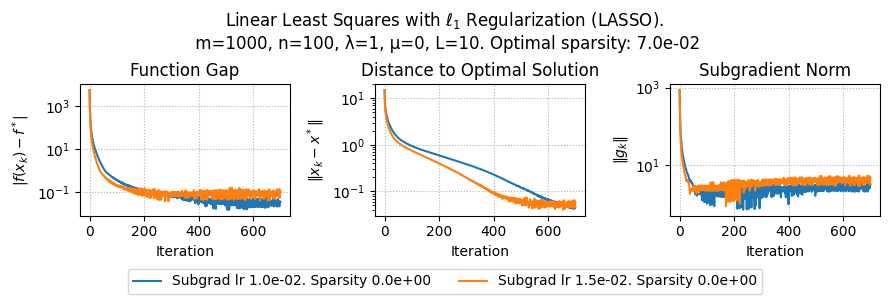

In [244]:
problem_params = {
    "m": 1000,  # number of samples
    "n": 100,   # number of features
    "mu": 0,    # strong convexity parameter (0 for LASSO)
    "L": 10,     # smoothness parameter
    "lambda": 1,  # regularization parameter
    "sparsity": 0,  # target sparsity of the true solution
    "noise": 0.1,     # noise level
    "methods": [
        {"method": "Subgrad", "learning_rate": 1e-2, "iterations": 700},
        {"method": "Subgrad", "learning_rate": 1.5e-2, "iterations": 700},
        # {"method": "Proximal", "learning_rate": 0.1, "iterations": 200},
        # {"method": "FISTA", "learning_rate": 0.1, "iterations": 200}
    ]
}

# Run experiments
results, params = run_experiments(problem_params)

# Plot results
plot_results(results, params)

Requested spectrum bounds: mu=0, L=10, condition number=infinite
Actual spectrum bounds: mu=0.000000, L=10.000000, condition number=4140226046578711.500000
Optimal solution sparsity: 2.30e-01


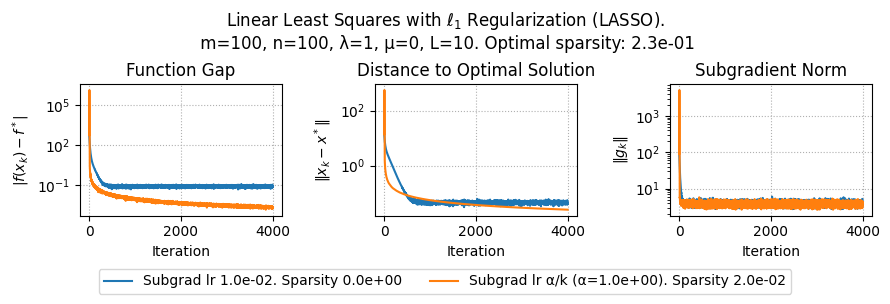

In [13]:
# Example usage:
params = {
    "m": 100,  # number of samples
    "n": 100,   # number of features
    "mu": 0,    # strong convexity parameter (0 for LASSO)
    "L": 10,     # smoothness parameter
    "lambda": 1,  # regularization parameter
    "sparsity": 0,  # target sparsity of the true solution
    "noise": 0.1,     # noise level
    "methods": [
        {"method": "Subgrad", "learning_rate": 1e-2, "iterations": 4000},  # Constant learning rate
        {"method": "Subgrad", "learning_rate": create_1_over_k_lr(1e0), "iterations": 4000},  # 1/k learning rate with alpha=0.5
        # {"method": "Proximal", "learning_rate": 0.1, "iterations": 1000},
        # {"method": "FISTA", "learning_rate": 0.1, "iterations": 1000}
    ]
}

results, params = run_experiments(params)
plot_results(results, params)

Requested spectrum bounds: mu=0, L=10, condition number=infinite
Actual spectrum bounds: mu=0.000000, L=10.000000, condition number=4140226046578711.500000
Optimal solution sparsity: 2.30e-01


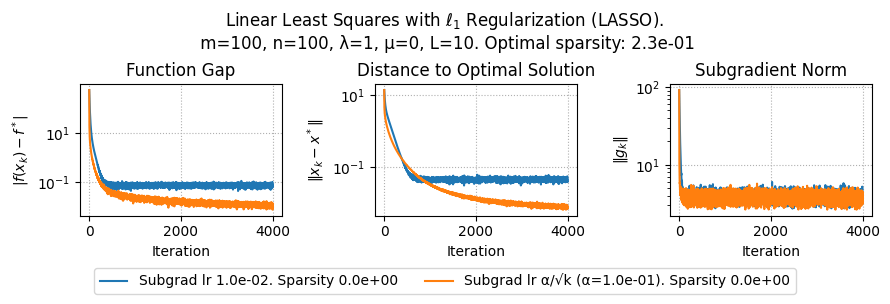

In [12]:
# Example usage:
params = {
    "m": 100,  # number of samples
    "n": 100,   # number of features
    "mu": 0,    # strong convexity parameter (0 for LASSO)
    "L": 10,     # smoothness parameter
    "lambda": 1,  # regularization parameter
    "sparsity": 0,  # target sparsity of the true solution
    "noise": 0.1,     # noise level
    "methods": [
        {"method": "Subgrad", "learning_rate": 0.01, "iterations": 4000},  # Constant learning rate
        {"method": "Subgrad", "learning_rate": create_1_over_sqrt_k_lr(1e-1), "iterations": 4000},  # 1/k learning rate with alpha=0.5
        # {"method": "Proximal", "learning_rate": 0.1, "iterations": 1000},
        # {"method": "FISTA", "learning_rate": 0.1, "iterations": 1000}
    ]
}

results, params = run_experiments(params)
plot_results(results, params)

Requested spectrum bounds: mu=0, L=10, condition number=infinite
Actual spectrum bounds: mu=0.000000, L=10.000000, condition number=4140226046578711.500000
Optimal solution sparsity: 2.30e-01


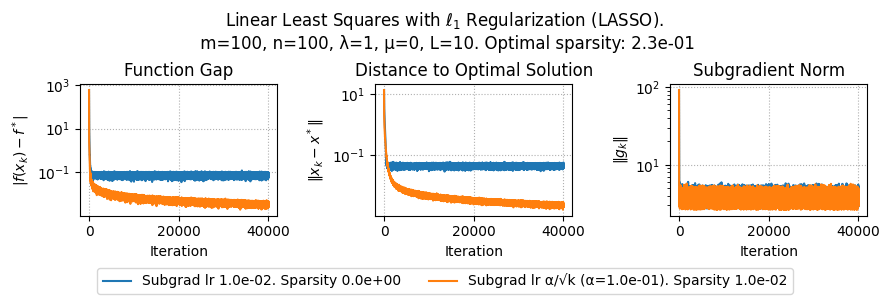

In [14]:
# Example usage:
params = {
    "m": 100,  # number of samples
    "n": 100,   # number of features
    "mu": 0,    # strong convexity parameter (0 for LASSO)
    "L": 10,     # smoothness parameter
    "lambda": 1,  # regularization parameter
    "sparsity": 0,  # target sparsity of the true solution
    "noise": 0.1,     # noise level
    "methods": [
        {"method": "Subgrad", "learning_rate": 0.01, "iterations": 40000},  # Constant learning rate
        {"method": "Subgrad", "learning_rate": create_1_over_sqrt_k_lr(1e-1), "iterations": 40000},  # 1/k learning rate with alpha=0.5
        # {"method": "Proximal", "learning_rate": 0.1, "iterations": 1000},
        # {"method": "FISTA", "learning_rate": 0.1, "iterations": 1000}
    ]
}

results, params = run_experiments(params)
plot_results(results, params)

Requested spectrum bounds: mu=1, L=10, condition number=10.000000
Actual spectrum bounds: mu=1.000000, L=10.000000, condition number=10.000000
Optimal solution sparsity: 2.00e-01


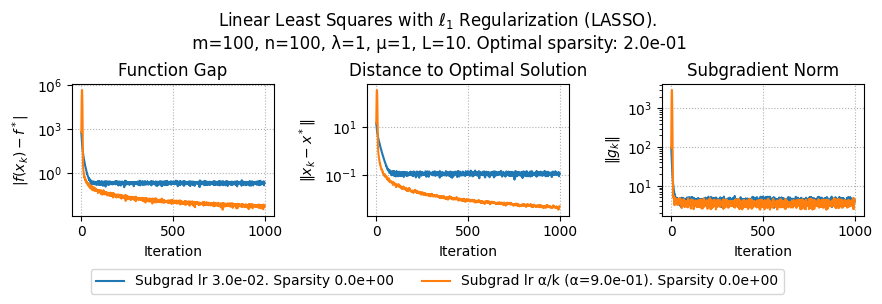

In [22]:
# Example usage:
params = {
    "m": 100,  # number of samples
    "n": 100,   # number of features
    "mu": 1,    # strong convexity parameter (0 for LASSO)
    "L": 10,     # smoothness parameter
    "lambda": 1,  # regularization parameter
    "sparsity": 0,  # target sparsity of the true solution
    "noise": 0.1,     # noise level
    "methods": [
        {"method": "Subgrad", "learning_rate": 3e-2, "iterations": 1000},  # Constant learning rate
        {"method": "Subgrad", "learning_rate": create_1_over_k_lr(9e-1), "iterations": 1000},
        # {"method": "Subgrad", "learning_rate": create_1_over_sqrt_k_lr(3e-1), "iterations": 1000},  # 1/k learning rate with alpha=0.5
        # {"method": "Proximal", "learning_rate": 0.1, "iterations": 1000},
        # {"method": "FISTA", "learning_rate": 0.1, "iterations": 1000}
    ]
}

results, params = run_experiments(params)
plot_results(results, params)

Requested spectrum bounds: mu=1, L=10, condition number=10.000000
Actual spectrum bounds: mu=1.000000, L=10.000000, condition number=10.000000
Optimal solution sparsity: 2.00e-01


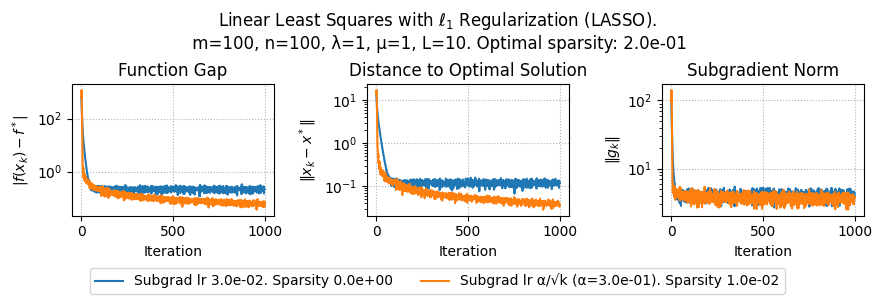

In [21]:
# Example usage:
params = {
    "m": 100,  # number of samples
    "n": 100,   # number of features
    "mu": 1,    # strong convexity parameter (0 for LASSO)
    "L": 10,     # smoothness parameter
    "lambda": 1,  # regularization parameter
    "sparsity": 0,  # target sparsity of the true solution
    "noise": 0.1,     # noise level
    "methods": [
        {"method": "Subgrad", "learning_rate": 3e-2, "iterations": 1000},  # Constant learning rate
        # {"method": "Subgrad", "learning_rate": create_1_over_k_lr(9e-1), "iterations": 1000},
        {"method": "Subgrad", "learning_rate": create_1_over_sqrt_k_lr(3e-1), "iterations": 1000},  # 1/k learning rate with alpha=0.5
        # {"method": "Proximal", "learning_rate": 0.1, "iterations": 1000},
        # {"method": "FISTA", "learning_rate": 0.1, "iterations": 1000}
    ]
}

results, params = run_experiments(params)
plot_results(results, params)

# Binary logistic regression with $\ell_1$ regularization

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import jax
from jax import numpy as jnp, grad, jit
from scipy.optimize import minimize_scalar
import time
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Set a random seed for reproducibility
jax.config.update("jax_enable_x64", True)

def fix_seed(seed=228):
    np.random.seed(seed)
    jax.random.PRNGKey(seed)

# Define the logistic loss function
@jit
def logistic_loss(w, X, y):
    m = len(X)
    z = X @ w
    # Numerically stable version of logistic loss
    loss = jnp.mean(jnp.logaddexp(0, -y * z))
    return loss

# Compute predictions and accuracy for binary classification
@jit
def compute_accuracy(w, X, y):
    predictions = jnp.sign(X @ w)
    return jnp.mean(predictions == y)

# Compute the optimal solution using CVXPY
def compute_optimal(X, y, lam):
    m, n = X.shape
    
    # Define the variable for weights
    w = cp.Variable(n)
    
    # Construct the objective: logistic loss + L1 regularization
    z = X @ w
    # CVXPY implementation of logistic loss
    logistic = cp.sum(cp.logistic(cp.multiply(-y, z))) / m
    l1_reg = lam * cp.norm1(w)
    
    # Total loss
    loss = logistic + l1_reg
    
    # Define the problem
    problem = cp.Problem(cp.Minimize(loss))
    
    # Solve the problem
    problem.solve()
    
    # Extract the optimal weights and minimum loss
    w_star = w.value
    f_star = problem.value
    
    return w_star, f_star

# Generate synthetic classification problem
def generate_problem(params):
    fix_seed()
    m = params["m"]  # number of samples
    n = params["n"]  # number of features
    
    # Generate a binary classification dataset
    X, y = make_classification(
        n_samples=m,
        n_features=n,
        n_informative=int(n * 0.8),
        n_redundant=int(n * 0.1),
        n_repeated=0,
        n_classes=2,
        random_state=228,
        class_sep=2.0
    )
    
    # Convert labels to -1, 1 for logistic regression
    y = 2 * y - 1
    
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=228)
    
    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Verify the actual condition number
    H = X_train.T @ X_train / len(X_train)
    actual_eigenvalues = np.linalg.eigvalsh(H)
    actual_mu = np.min(actual_eigenvalues)
    actual_L = np.max(actual_eigenvalues)
    
    mu = params.get("mu", 0.0)
    L = params.get("L", 10.0)
    condition_str = "infinite" if mu == 0 else f"{L/mu:.6f}"
    print(f"Requested spectrum bounds: mu={mu}, L={L}, condition number={condition_str}")
    print(f"Actual spectrum bounds: mu={actual_mu:.6f}, L={actual_L:.6f}, condition number={actual_L/actual_mu:.6f}")
    
    return X_train, y_train, X_test, y_test

# Helper function to create a 1/sqrt(k) learning rate strategy
def create_1_over_sqrt_k_lr(alpha):
    """
    Creates a learning rate function that returns alpha/sqrt(k) where k is the iteration number.
    
    Args:
        alpha: Scaling factor for the learning rate
        
    Returns:
        A function that takes an iteration number k and returns alpha/sqrt(k)
    """
    def one_over_sqrt_k_lr(k):
        # Avoid division by zero for k=0
        k_safe = max(k, 1)
        return alpha / (k_safe**0.5)
    
    return one_over_sqrt_k_lr

# Helper function to create a 1/k learning rate strategy
def create_1_over_k_lr(alpha):
    """
    Creates a learning rate function that returns alpha/k where k is the iteration number.
    
    Args:
        alpha: Scaling factor for the learning rate
        
    Returns:
        A function that takes an iteration number k and returns alpha/k
    """
    def one_over_k_lr(k):
        # Avoid division by zero for k=0
        k_safe = max(k, 1)
        return alpha / k_safe
    
    return one_over_k_lr

# Subgradient descent method
def subgradient_descent(w_0, X_train, y_train, X_test, y_test, learning_rate, num_iters, lam):
    fix_seed()
    trajectory = [w_0]
    times = [0]
    train_accuracies = [compute_accuracy(w_0, X_train, y_train)]
    test_accuracies = [compute_accuracy(w_0, X_test, y_test)]
    
    w = w_0
    f = lambda w: logistic_loss(w, X_train, y_train)
    
    iter_start = time.time()
    for i in range(num_iters):
        # Determine the current learning rate
        if callable(learning_rate):
            # If learning_rate is a function, call it with the current iteration
            current_lr = learning_rate(i+1)
        else:
            # Otherwise, use the constant learning rate
            current_lr = learning_rate
            
        grad_val = grad(f)(w)
        subgrad_val = grad_val + lam * jnp.sign(w)
        
        w = w - current_lr * subgrad_val
        
        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)
        train_accuracies.append(compute_accuracy(w, X_train, y_train))
        test_accuracies.append(compute_accuracy(w, X_test, y_test))
    
    return trajectory, times, train_accuracies, test_accuracies

# Soft thresholding operator for proximal gradient method
def soft_thresholding(x, kappa):
    return jnp.sign(x) * jnp.maximum(jnp.abs(x) - kappa, 0)

# Proximal gradient method (ISTA)
def proximal_gradient_method(w_0, X_train, y_train, X_test, y_test, learning_rate, num_iters, lam):
    trajectory = [w_0]
    times = [0]
    train_accuracies = [compute_accuracy(w_0, X_train, y_train)]
    test_accuracies = [compute_accuracy(w_0, X_test, y_test)]
    
    w = w_0
    f = lambda w: logistic_loss(w, X_train, y_train)
    
    iter_start = time.time()
    for i in range(num_iters):
        grad_val = grad(f)(w)
        
        w = soft_thresholding(w - learning_rate * grad_val, learning_rate * lam)
        
        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)
        train_accuracies.append(compute_accuracy(w, X_train, y_train))
        test_accuracies.append(compute_accuracy(w, X_test, y_test))
    
    return trajectory, times, train_accuracies, test_accuracies

# Accelerated proximal gradient method (FISTA)
def accelerated_proximal_gradient(w_0, X_train, y_train, X_test, y_test, learning_rate, num_iters, lam):
    trajectory = [w_0]
    times = [0]
    train_accuracies = [compute_accuracy(w_0, X_train, y_train)]
    test_accuracies = [compute_accuracy(w_0, X_test, y_test)]
    
    w = w_0
    z = w_0
    t = 1
    
    f = lambda w: logistic_loss(w, X_train, y_train)
    
    iter_start = time.time()
    for i in range(num_iters):
        grad_val = grad(f)(z)
        
        w_next = soft_thresholding(z - learning_rate * grad_val, learning_rate * lam)
        
        t_next = (1 + jnp.sqrt(1 + 4 * t**2)) / 2
        z = w_next + ((t - 1) / t_next) * (w_next - w)
        
        w = w_next
        t = t_next
        
        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)
        train_accuracies.append(compute_accuracy(w, X_train, y_train))
        test_accuracies.append(compute_accuracy(w, X_test, y_test))
    
    return trajectory, times, train_accuracies, test_accuracies

# Compute metrics
def compute_metrics(trajectory, x_star, f_star, train_accuracies, test_accuracies, times, X_train, y_train, lam):
    f = lambda w: logistic_loss(w, X_train, y_train) + lam * jnp.sum(jnp.abs(w))
    
    metrics = {
        "f_gap": [jnp.abs(f(x) - f_star) for x in trajectory],
        "x_gap": [jnp.linalg.norm(x - x_star) for x in trajectory],
        "train_accuracy": train_accuracies,
        "test_accuracy": test_accuracies,
        "time": times,
        "sparsity": [jnp.mean(jnp.abs(x) < 1e-5) for x in trajectory]
    }
    return metrics

def run_experiments(params):
    lam = params["lambda"]
    methods = params["methods"]
    results = {}

    X_train, y_train, X_test, y_test = generate_problem(params)
    n_features = X_train.shape[1]
    
    # Initialize with zeros
    x_0 = jax.random.normal(jax.random.PRNGKey(0), (n_features, ))
    
    # Compute optimal solution
    x_star, f_star = compute_optimal(X_train, y_train, lam)
    optimal_sparsity = np.mean(np.abs(x_star) < 1e-5)
    print(f"Optimal solution sparsity: {optimal_sparsity:.2e}")
    params["optimal_sparsity"] = optimal_sparsity
    print(f"Optimal train accuracy: {compute_accuracy(x_star, X_train, y_train):.4f}")
    print(f"Optimal test accuracy: {compute_accuracy(x_star, X_test, y_test):.4f}")

    for method in methods:
        if method["method"] == "Subgrad":
            learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            
            # Handle different learning rate strategies
            if isinstance(learning_rate, (int, float)):
                # Constant learning rate
                lr_label = f" lr {learning_rate:.1e}"
            elif callable(learning_rate):
                # Try to determine the type of learning rate scheduler
                if hasattr(learning_rate, "__name__"):
                    if learning_rate.__name__ == "one_over_k_lr":
                        # 1/k learning rate
                        alpha = learning_rate.__closure__[0].cell_contents
                        lr_label = f" lr α/k (α={alpha:.1e})"
                    elif learning_rate.__name__ == "one_over_sqrt_k_lr":
                        # 1/sqrt(k) learning rate
                        alpha = learning_rate.__closure__[0].cell_contents
                        lr_label = f" lr α/√k (α={alpha:.1e})"
                    else:
                        lr_label = " lr custom"
                elif hasattr(learning_rate, "__closure__") and learning_rate.__closure__:
                    # Try to extract the alpha value from the closure
                    try:
                        alpha = learning_rate.__closure__[0].cell_contents
                        # Check the function body to determine if it's 1/k or 1/sqrt(k)
                        func_code = learning_rate.__code__.co_consts
                        if any("k**0.5" in str(const) for const in func_code if isinstance(const, str)):
                            lr_label = f" lr α/√k (α={alpha:.1e})"
                        elif any("k**1" in str(const) for const in func_code if isinstance(const, str)):
                            lr_label = f" lr α/k (α={alpha:.1e})"
                        else:
                            lr_label = " lr custom"
                    except:
                        lr_label = " lr custom"
                else:
                    lr_label = " lr custom"
            else:
                # Default to unknown if not recognized
                lr_label = " lr unknown"
                
            trajectory, times, train_accuracies, test_accuracies = subgradient_descent(
                x_0, X_train, y_train, X_test, y_test, learning_rate, iterations, lam
            )
            label = method["method"] + lr_label
            results[label] = compute_metrics(
                trajectory, x_star, f_star, train_accuracies, test_accuracies, times, X_train, y_train, lam
            )
        
        elif method["method"] == "Proximal":
            learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            trajectory, times, train_accuracies, test_accuracies = proximal_gradient_method(
                x_0, X_train, y_train, X_test, y_test, learning_rate, iterations, lam
            )
            label = method["method"] + f" lr {learning_rate:.1e}"
            results[label] = compute_metrics(
                trajectory, x_star, f_star, train_accuracies, test_accuracies, times, X_train, y_train, lam
            )
        
        elif method["method"] == "FISTA":
            learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            trajectory, times, train_accuracies, test_accuracies = accelerated_proximal_gradient(
                x_0, X_train, y_train, X_test, y_test, learning_rate, iterations, lam
            )
            label = method["method"] + f" lr {learning_rate:.1e}"
            results[label] = compute_metrics(
                trajectory, x_star, f_star, train_accuracies, test_accuracies, times, X_train, y_train, lam
            )

    return results, params

def plot_results(results, params):
    plt.figure(figsize=(9, 3))
    lam = params["lambda"]
    
    plt.suptitle(f"Binary Logistic Regression with $\ell_1$ Regularization.\n m={params['m']}, n={params['n']}, λ={lam}. Optimal sparsity: {params['optimal_sparsity']:.1e}")

    # Plot function gap vs iterations
    plt.subplot(1, 4, 1)
    for method, metrics in results.items():
        plt.plot(metrics['f_gap'], label=method + f". Sparsity {metrics['sparsity'][-1]:.1e}")
    plt.xlabel('Iteration')
    plt.ylabel(r'$|f(x_k) - f^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")
    plt.title('Function Gap')

    plt.subplot(1, 4, 2)
    for method, metrics in results.items():
        plt.plot(metrics['x_gap'])
    plt.xlabel('Iteration')
    plt.ylabel(r'$|x_k - x^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")
    plt.title('Domain Gap')

    # Plot train accuracy vs iterations
    plt.subplot(1, 4, 3)
    for method, metrics in results.items():
        plt.plot(metrics['train_accuracy'])
    plt.xlabel('Iteration')
    plt.ylabel('Accuracy')
    plt.grid(linestyle=":")
    plt.title('Train Accuracy')

    # Plot test accuracy vs iterations
    plt.subplot(1, 4, 4)
    for method, metrics in results.items():
        plt.plot(metrics['test_accuracy'])
    plt.xlabel('Iteration')
    plt.ylabel('Accuracy')
    plt.grid(linestyle=":")
    plt.title('Test Accuracy')

    # Place the legend below the plots
    plt.figlegend(loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.01))
    
    # Adjust layout to make space for the legend below
    filename = f"logistic_m_{params['m']}_n_{params['n']}_lambda_{params['lambda']}.pdf"
    plt.tight_layout(rect=[0, 0.1, 1, 1.05])
    plt.savefig(filename)
    plt.show()

Requested spectrum bounds: mu=0.0, L=10.0, condition number=infinite
Actual spectrum bounds: mu=-0.000000, L=4.451426, condition number=-7017042033266276.000000
Optimal solution sparsity: 8.60e-01
Optimal train accuracy: 0.8875
Optimal test accuracy: 0.8667


/Users/bratishka/.pyenv/versions/3.9.17/envs/benchmarx/lib/python3.9/site-packages/cvxpy/reductions/solvers/solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


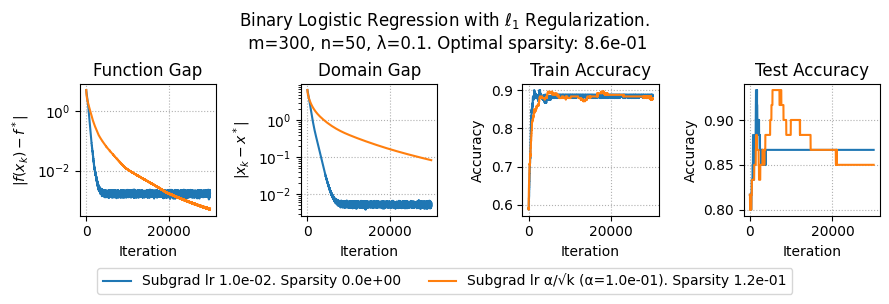

In [47]:
# Example usage:
params = {
    "m": 300,  # number of samples
    "n": 50,   # number of features
    "lambda": 0.1,  # regularization parameter
    "sparsity": 0,  # target sparsity of the true solution
    "noise": 0.1,     # noise level
    "methods": [
        {"method": "Subgrad", "learning_rate": 1e-2, "iterations": 30000},  # Constant learning rate
        # {"method": "Subgrad", "learning_rate": create_1_over_k_lr(9e-1), "iterations": 1000},
        {"method": "Subgrad", "learning_rate": create_1_over_sqrt_k_lr(1e-1), "iterations": 30000},  
        # {"method": "Proximal", "learning_rate": 0.1, "iterations": 1000},
        # {"method": "FISTA", "learning_rate": 0.1, "iterations": 1000}
    ]
}

results, params = run_experiments(params)
plot_results(results, params)

Requested spectrum bounds: mu=0.0, L=10.0, condition number=infinite
Actual spectrum bounds: mu=-0.000000, L=4.451426, condition number=-7017042033266276.000000
Optimal solution sparsity: 9.60e-01
Optimal train accuracy: 0.7333
Optimal test accuracy: 0.7333


/Users/bratishka/.pyenv/versions/3.9.17/envs/benchmarx/lib/python3.9/site-packages/cvxpy/reductions/solvers/solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


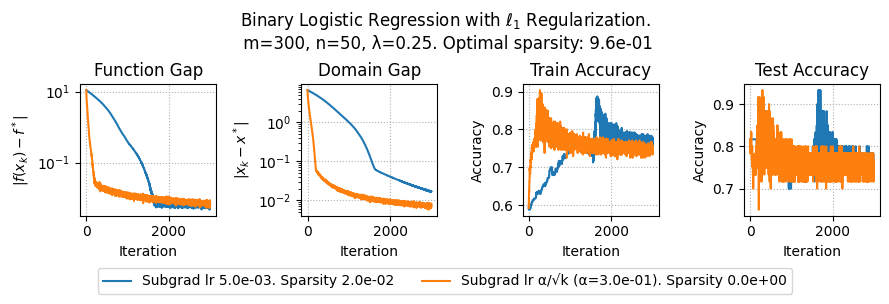

In [62]:
# Example usage:
params = {
    "m": 300,  # number of samples
    "n": 50,   # number of features
    "lambda": 0.25,  # regularization parameter
    "sparsity": 0,  # target sparsity of the true solution
    "noise": 0.1,     # noise level
    "methods": [
        {"method": "Subgrad", "learning_rate": 5e-3, "iterations": 3000},  # Constant learning rate
        # {"method": "Subgrad", "learning_rate": create_1_over_k_lr(9e-1), "iterations": 1000},
        {"method": "Subgrad", "learning_rate": create_1_over_sqrt_k_lr(3e-1), "iterations": 3000},  
        # {"method": "Proximal", "learning_rate": 0.1, "iterations": 1000},
        # {"method": "FISTA", "learning_rate": 0.1, "iterations": 1000}
    ]
}

results, params = run_experiments(params)
plot_results(results, params)

Requested spectrum bounds: mu=0.0, L=10.0, condition number=infinite
Actual spectrum bounds: mu=-0.000000, L=4.451426, condition number=-7017042033266276.000000
Optimal solution sparsity: 9.60e-01
Optimal train accuracy: 0.7333
Optimal test accuracy: 0.7333


/Users/bratishka/.pyenv/versions/3.9.17/envs/benchmarx/lib/python3.9/site-packages/cvxpy/reductions/solvers/solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


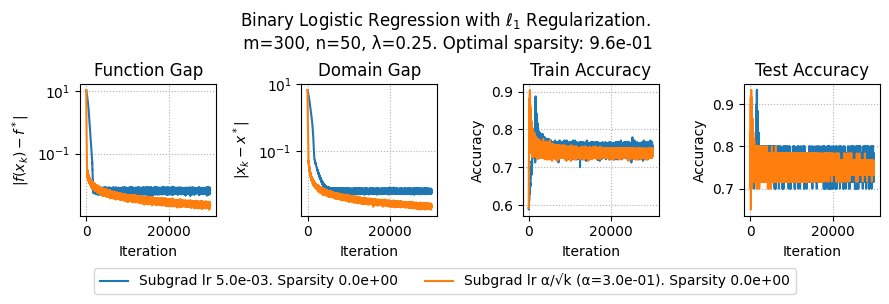

In [63]:
# Example usage:
params = {
    "m": 300,  # number of samples
    "n": 50,   # number of features
    "lambda": 0.25,  # regularization parameter
    "sparsity": 0,  # target sparsity of the true solution
    "noise": 0.1,     # noise level
    "methods": [
        {"method": "Subgrad", "learning_rate": 5e-3, "iterations": 30000},  # Constant learning rate
        # {"method": "Subgrad", "learning_rate": create_1_over_k_lr(9e-1), "iterations": 1000},
        {"method": "Subgrad", "learning_rate": create_1_over_sqrt_k_lr(3e-1), "iterations": 30000},  
        # {"method": "Proximal", "learning_rate": 0.1, "iterations": 1000},
        # {"method": "FISTA", "learning_rate": 0.1, "iterations": 1000}
    ]
}

results, params = run_experiments(params)
plot_results(results, params)

Requested spectrum bounds: mu=0.0, L=10.0, condition number=infinite
Actual spectrum bounds: mu=-0.000000, L=4.451426, condition number=-7017042033266276.000000
Optimal solution sparsity: 1.00e+00
Optimal train accuracy: 0.7833
Optimal test accuracy: 0.7667


/Users/bratishka/.pyenv/versions/3.9.17/envs/benchmarx/lib/python3.9/site-packages/cvxpy/reductions/solvers/solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


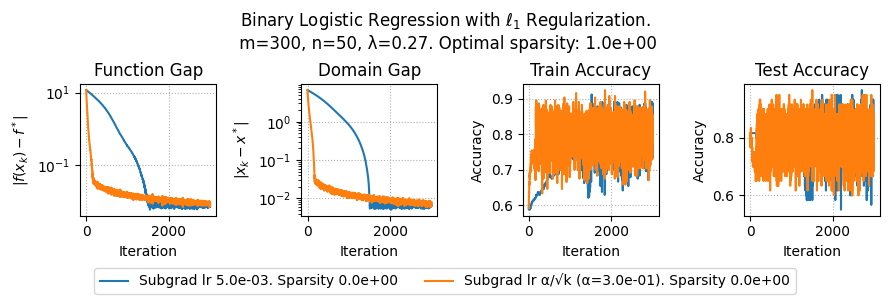

In [64]:
# Example usage:
params = {
    "m": 300,  # number of samples
    "n": 50,   # number of features
    "lambda": 0.27,  # regularization parameter
    "sparsity": 0,  # target sparsity of the true solution
    "noise": 0.1,     # noise level
    "methods": [
        {"method": "Subgrad", "learning_rate": 5e-3, "iterations": 3000},  # Constant learning rate
        # {"method": "Subgrad", "learning_rate": create_1_over_k_lr(9e-1), "iterations": 1000},
        {"method": "Subgrad", "learning_rate": create_1_over_sqrt_k_lr(3e-1), "iterations": 3000},  
        # {"method": "Proximal", "learning_rate": 0.1, "iterations": 1000},
        # {"method": "FISTA", "learning_rate": 0.1, "iterations": 1000}
    ]
}

results, params = run_experiments(params)
plot_results(results, params)

Requested spectrum bounds: mu=0.0, L=10.0, condition number=infinite
Actual spectrum bounds: mu=-0.000000, L=4.451426, condition number=-7017042033266276.000000
Optimal solution sparsity: 1.00e+00
Optimal train accuracy: 0.7833
Optimal test accuracy: 0.7667


/Users/bratishka/.pyenv/versions/3.9.17/envs/benchmarx/lib/python3.9/site-packages/cvxpy/reductions/solvers/solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


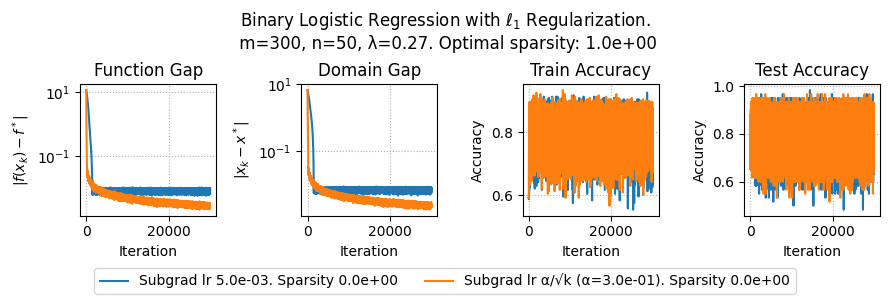

In [65]:
# Example usage:
params = {
    "m": 300,  # number of samples
    "n": 50,   # number of features
    "lambda": 0.27,  # regularization parameter
    "sparsity": 0,  # target sparsity of the true solution
    "noise": 0.1,     # noise level
    "methods": [
        {"method": "Subgrad", "learning_rate": 5e-3, "iterations": 30000},  # Constant learning rate
        # {"method": "Subgrad", "learning_rate": create_1_over_k_lr(9e-1), "iterations": 1000},
        {"method": "Subgrad", "learning_rate": create_1_over_sqrt_k_lr(3e-1), "iterations": 30000},  
        # {"method": "Proximal", "learning_rate": 0.1, "iterations": 1000},
        # {"method": "FISTA", "learning_rate": 0.1, "iterations": 1000}
    ]
}

results, params = run_experiments(params)
plot_results(results, params)

# Softmax regression with $\ell_1$

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import jax
from jax import numpy as jnp, grad
from scipy.optimize import minimize_scalar
import jax.numpy as jnp
from jax import grad, jit, hessian
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
from ucimlrepo import fetch_ucirepo
from optax.losses import safe_softmax_cross_entropy as cros_entr

# Define softmax function
@jit
def softmax(z):
    exp_z = jnp.exp(z - jnp.max(z, axis=1, keepdims=True))
    return exp_z / exp_z.sum(axis=1, keepdims=True)

# Define cross-entropy loss
@jit
def cross_entropy_loss_log(w, X, y):
    predictions = X @ w
    n = len(X)
    log_likelihoods = jax.scipy.special.logsumexp(predictions, axis=1)
    cross_entropy = log_likelihoods - jnp.sum(jnp.multiply(predictions, y), axis=1)
    return (1/n) * jnp.sum(cross_entropy)

# Set a random seed for reproducibility
np.random.seed(228)
jax.random.PRNGKey(228)

def compute_optimal(X, y, lam):
    n, d = X.shape
    k = y.shape[1]  # Assuming y is one-hot encoded, number of classes

    # Define the variable for weights
    w = cp.Variable((d, k))
    
    # Construct the objective
    logits = X @ w
    log_likelihoods = cp.log_sum_exp(logits, axis=1)
    cross_entropy_loss = cp.sum(log_likelihoods) - cp.sum(cp.multiply(y, logits))
    
    # Add l1 regularization
    l1_reg = lam * cp.sum(cp.abs(w))
    
    # Total loss
    loss = (1/n) * cross_entropy_loss + l1_reg
    
    # Define the problem
    problem = cp.Problem(cp.Minimize(loss))
    
    # Solve the problem
    problem.solve()
    
    # Extract the optimal weights and minimum loss
    w_star = w.value
    f_star = problem.value
    
    return w_star, f_star

def generate_problem():
    # Fetch dataset from UCI repository
    dataset = fetch_ucirepo(id=697)
    
    # Extract features and targets
    X = dataset.data.features.values
    y = dataset.data.targets.values.flatten()

    # Create a mapping from unique labels to integers
    unique_labels = np.unique(y)
    num_classes = len(unique_labels)
    label_to_int = {label: idx for idx, label in enumerate(unique_labels)}

    # Convert labels to integers using the mapping
    y_integers = jnp.array([label_to_int[label] for label in y])

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y_integers, test_size=0.33, random_state=42)

    # Normalize the data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # One-hot encoding using jax
    y_train_one_hot = jax.nn.one_hot(y_train, num_classes)
    y_test_one_hot = jax.nn.one_hot(y_test, num_classes)

    return X_train, y_train_one_hot, X_test, y_test_one_hot

def subgradient_descent(w_0, X, y, learning_rate=0.01, num_iters=100, lam=1):
    trajectory = [w_0]
    times = [0]
    w = w_0
    f = lambda w: cross_entropy_loss_log(w, X, y)

    iter_start = time.time()
    for i in range(num_iters):
        grad_val = grad(f)(w)
        subgrad_val = grad_val + lam * jnp.sign(w)
        w -= learning_rate * subgrad_val
        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)
    return trajectory, times

def soft_thresholding(x, kappa):
    return jnp.sign(x) * jnp.maximum(jnp.abs(x) - kappa, 0)

def proximal_gradient_method(w_0, X, y, learning_rate=0.01, num_iters=100, lam=1):
    trajectory = [w_0]
    times = [0]
    w = w_0
    f = lambda w: cross_entropy_loss_log(w, X, y) 

    iter_start = time.time()
    for i in range(num_iters):
        grad_val = grad(f)(w)
        w = soft_thresholding(w - learning_rate * grad_val, learning_rate*lam)
        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)
    return trajectory, times

# Compute accuracy
def compute_accuracy(w, X, y):
    predictions = softmax(X @ w)
    predicted_classes = jnp.argmax(predictions, axis=1)
    true_classes = jnp.argmax(y, axis=1)
    accuracy = jnp.mean(predicted_classes == true_classes)
    return accuracy

# Compute metrics
def compute_metrics(trajectory, x_star, f_star, times, X_train, y_train, X_test, y_test, lam):
    f = lambda w: cross_entropy_loss_log(w, X_train, y_train) + lam * jnp.sum(jnp.abs(w))
    metrics = {
        "f_gap": [jnp.abs(f(x) - f_star) for x in trajectory],
        "x_gap": [jnp.linalg.norm(x - x_star) for x in trajectory],
        "time": times,
        "train_acc": [compute_accuracy(x, X_train, y_train) for x in trajectory],
        "test_acc": [compute_accuracy(x, X_test, y_test) for x in trajectory],
        "sparsity": [jnp.mean(jnp.abs(x) < 1e-5) for x in trajectory]
    }
    return metrics

def run_experiments(params):
    lam = params["lam"]
    methods = params["methods"]
    results = {}

    X_train, y_train, X_test, y_test = generate_problem()
    n_features = X_train.shape[1]
    n_classes = len(y_train[0])
    params["n_features"], params["n_classes"] = n_features, n_classes
    
    x_0 = jax.random.normal(jax.random.PRNGKey(0), (n_features, n_classes))
    x_star, f_star = compute_optimal(X_train, y_train, lam)
    print(f"Optimal accuracy {compute_accuracy(x_star, X_train, y_train)}")

    for method in methods:
        if method["method"] == "Subgrad":
            learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            trajectory, times = subgradient_descent(x_0, X_train, y_train, learning_rate, iterations, lam)
            label = method["method"] + f" lr {learning_rate:.2f}"
            results[label] = compute_metrics(trajectory, x_star, f_star, times, X_train, y_train, X_test, y_test, lam)
        elif method["method"] == "Proximal":
            learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            trajectory, times = proximal_gradient_method(x_0, X_train, y_train, learning_rate, iterations, lam)
            label = method["method"] + f" lr {learning_rate:.2f}"
            results[label] = compute_metrics(trajectory, x_star, f_star, times, X_train, y_train, X_test, y_test, lam)

    return results, params

def plot_results(results, params):
    plt.figure(figsize=(11, 5))
    lam = params["lam"]
    
    plt.suptitle(f"Convex multiclass regression. lam={lam}.")

    plt.subplot(2, 4, 1)
    for method, metrics in results.items():
        plt.plot(metrics['f_gap'])
    plt.xlabel('Iteration')
    plt.ylabel(r'$|f(x) -f^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 2)
    for method, metrics in results.items():
        plt.plot(metrics['x_gap'], label=method + f" sparsity {metrics['sparsity'][-1]:.3f}")
    plt.xlabel('Iteration')
    plt.ylabel('$\|x_k - x^*\|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 3)
    for method, metrics in results.items():
        plt.plot(metrics["train_acc"])
    plt.xlabel('Iteration')
    plt.ylabel('Train accuracy')
    # plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 4)
    for method, metrics in results.items():
        plt.plot(metrics["test_acc"])
    plt.xlabel('Iteration')
    plt.ylabel('Test accuracy')
    # plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 5)
    for method, metrics in results.items():
        plt.plot(metrics["time"], metrics['f_gap'])
    plt.xlabel('Time')
    plt.ylabel(r'$|f(x) -f^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 6)
    for method, metrics in results.items():
        plt.plot(metrics["time"], metrics['x_gap'])
    plt.xlabel('Time')
    plt.ylabel('$\|x_k - x^*\|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 7)
    for method, metrics in results.items():
        plt.plot(metrics["time"], metrics["train_acc"])
    plt.xlabel('Time')
    plt.ylabel('Train accuracy')
    # plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 8)
    for method, metrics in results.items():
        plt.plot(metrics["time"], metrics["test_acc"])
    plt.xlabel('Time')
    plt.ylabel('Test accuracy')
    # plt.yscale('log')
    plt.grid(linestyle=":")

    # Place the legend below the plots
    plt.figlegend(loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.00))
    # Adjust layout to make space for the legend below
    filename = ""
    for method, metrics in results.items():
        filename += method
    filename += f"_{lam}.pdf"
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(filename)
    plt.show()

/Users/bratishka/.pyenv/versions/3.9.17/envs/benchmarx/lib/python3.9/site-packages/cvxpy/reductions/solvers/solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


Optimal accuracy 0.7763157486915588


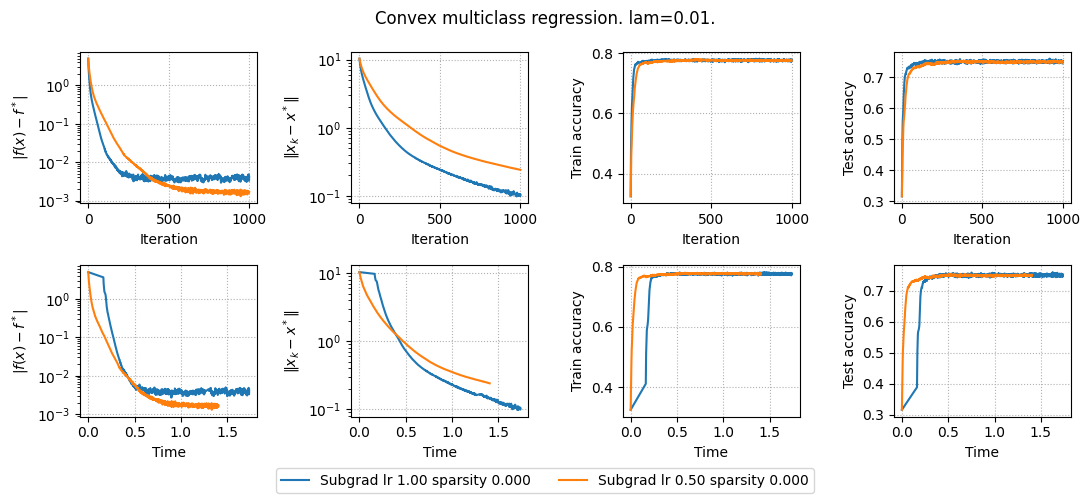

In [24]:
params = {
    "lam": 1e-2,
    "methods": [
        {
            "method": "Subgrad",
            "learning_rate": 1,
            "iterations": 1000,
        },
          {
            "method": "Subgrad",
            "learning_rate": 5e-1,
            "iterations": 1000,
        },
    ]
}

results, params = run_experiments(params)
plot_results(results, params)